# Mitigating Shortcut Learning in Chest X-Ray Classification via Adaptive ROI Cropping

Terms to define:
- Shortcut learning
- Supervised Learning
- Overfitting
- Normalisation
- Adam Optimiser

## Abstract
Convolutional Nueral Networks (CNNs) are being rapidly deployed and demonstrated their poweerful performance in medical scanning technology. Interpretability methods, such as Grad-CAM, often highlights that alot of the attention of the CNN is clinically irrelavent, indicating that *shortcut learning* may be in place.
<br><br>
In this project, I investigate whether adaptive spatial preprocessing (automatic region-of-interest [ROI] cropping) is an effective way to reduce background bias and improve interpretability without degrading classification performance. 
<br><br>
Two CNN models are trained under the same conditions. Both however are being trained with different data. The first set is the standard resized images, whilst the second is using adaptively cropped images. The performance of both models are evaluated quantitatively, while Grad-CAM visualisations are used as a measure to assess anatimuical focus.

## Background & Motivations

### Why Interpretability Matters in Medical Imaging
High classification accuracy alone is not sufficient for medical imaging tasks. Model predictions must be interpretable and in conjunction with known anatomy so that there is a stable level of safetly, trust and clinical relevance.
<br><br>
Gradient-based attribution methods (like Grad-CAM) are widely used to render the regions of an image that influenced a model's prediciton. In the context of chest X-ray classficiation, these regions should correspond to pulmonary structures, not image borders or other scanner artifacts. 
<br><br>

### Obervation Issue of Model's Attention Outside the Lung Region
CNN's may frequently observe features outside of an ROI. If large samples of data have features that are not medically relevant, but are readily present, this can hinder the behaviour of how the model will learn. In this use case, I aim to see consider if there are features outside the thoracic cavity that may indicate any presence of shortcut learning.

## Project Goal:
- The goal of this project is to investigate whether spatial preprocessing (adaptive cropping of chest X-rays) improves model interpretability and reduces shortcut learning, without sacrificing classification performance, as evaluated using Grad-CAM.
<br>
<br>

This project compares two convolutional neural network (CNN) models trained to classify chest X-ray images (normal vs pneumonia): 
- One trained on standard resized images, 
- One trained on adaptively cropped images that isolate the chest region.

The motivation is to test whether removing irrelevant background and borders:
- Changes where the model “looks” (via Grad-CAM),
- Reduces attention to non-anatomical regions,
- Potentially improves or maintains predictive performance.



## Information About the Dataset
Link to dataset: 
<br><br>
This dataset contains images of X-ray scan. This includes images of two types of chest scans, one infected with pnuemonia and the other as normal (no infection). For labelling the data, I have set that 0 is for normal lungs and 1 is for pnuemonia positive lungs.

## Imports

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import os
import cv2 as cv 
import random
from sklearn.model_selection import train_test_split
import tensorflow as tf

## Image Analysis

### Loading the Data

In [2]:
path_train = "chest_xray/train/"
train = os.listdir(path_train)

In [3]:
folders = []
folders = [f for f in sorted(os.listdir(path_train)) if os.path.isdir(os.path.join(path_train, f))]
print(folders)

['NORMAL', 'PNEUMONIA']


In [4]:
labels = folders
print (f'The labels are {labels}')

The labels are ['NORMAL', 'PNEUMONIA']


#### Creating Training Data
The following function is used to develop the initial labeled dataset. This is done by loading the raw images of chest X-rays, tranforming them into a numerical format, and then assigning class labels required for supervised learning.

In [5]:
# Creating the training data by reading the images and resizing them to the specified size, and storing them in a list along with their corresponding labels.
def create_training_data(path):
    img_size = 256
    training_data_images = []
    for label in labels:
        direc = os.path.join(path, label)
        # Converts the folder names (Normal, Pneumonia) into numeric labels (0, 1) for training the model
        class_num = labels.index(label) # Assign a numeric label based on the index in the labels list
        for image in os.listdir(direc):
            if image.startswith('.'):
                continue
            # Load the image in grayscale
            image_read = cv.imread(os.path.join(direc,image), cv.IMREAD_GRAYSCALE) 
            # Skip images that failed to load or are corrupted
            if image_read is None:
                print(f"Warning: Could not load {image}")
                continue
            image_resized = cv.resize(image_read, (img_size, img_size)) # Standardize the image size 
            training_data_images.append([image_resized, class_num])
    return training_data_images

In [6]:
train = create_training_data(path_train)
print(f'Length of training data = {len(train)}')

Length of training data = 5216


## Train Validation Test Split
In *supervised learning*, datasets are usually split into three different subsets: training, validation and, testing. This allows for a model to be trained, enhanced, and evaluated on independent data. This lowers the chances of overfitting or extremely optimistic performance estimate.
<br><br>
We have two arrays defined, X and y. X is a list of all features in the data, whereas y is the labels (such as 0 and 1 / normal and pneumonia).
<br><br>
It is commonly considered that with large datasets, 80% of the data is used for training and 20% of the remaining data is used for testing. This data is split in a way that we use the majority of the data is used for training, while other sets of data can be used for model selection and performance review. This allows for reports to reflect accurate results that shows the model's ability to generalise unseen patient data.


In [7]:
X = []
y = []

for features, label in train:
    X.append(features)
    y.append(label)

print(f'Length of X = {len(X)}')
print(f'Length of y = {len(y)}')

X = np.array(X)
y = np.array(y)
y = np.expand_dims(y, axis=1)

Length of X = 5216
Length of y = 5216


The loop below shows us that 1073 images in the dataset are normal X-ray scans and 3099 images in the data are X-ray scans of pneumonia positive patients.

In [9]:
a = 0
b = 0

for label in y_train:
    if label == 0:
        a += 1
    elif label == 1:
        b += 1
    else:
        print(f"Warning: Found unexpected label {label}")

print(f'Number of Normal images in training set = {a}')
print(f'Number of Pneumonia images in training set = {b}')

Number of Normal images in training set = 1073
Number of Pneumonia images in training set = 3099


## Baseline Image Preprocessing
Prior to training the model, all images are resized to 128×128 pixels and normalised to the range [0, 1]. A smaller input resolution was chosen over the raw 256×256 as this would lower memory usage and decrease training time, which is acceptable given the proof-of-concept scope of this project. 
Whilst fine-grained spatial details may be reduced when downsampling, the chosen resolution remains valid for capturing global pumonary patterns that are relevant to pneumonia classification. This step of preprocessing ensures that there is a preservation of full image content, including background regions and positioning artifacts. This therefore has a purpose of being a basiline commonly utilised in CNN image classification pipelines. Each image also is required to have an explicity channel dimension, concluding in a final shape of (128, 128, 1), whit is compatible with the CNN architecture used in this project.

In [10]:
img_size = (128, 128)

def preprocess_image_array(image):
    # Resize to target input size for the CNN
    image_resized = cv.resize(image, img_size)
    image_resized = image_resized.astype(np.float32)
    # Normalize pixel values to [0, 1]
    if image_resized.max() > 1.0:
        image_resized = image_resized / 255.0
    # Add channel dimension: (128, 128) -> (128, 128, 1)
    return image_resized[..., np.newaxis]

In [11]:
X.shape
y = y.ravel()

y.shape

print(f'Final shape of X: {X.shape}')
print(f'Final shape of y: {y.shape}')

Final shape of X: (5216, 256, 256)
Final shape of y: (5216,)


### Test, Train Split

In [12]:
# Test with 20% Train with 80%
X_temp, X_test, y_temp, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=32, stratify=y_train)

# Split Training with 60% and Validation with 20%
X_train_final, X_val, y_train_final, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=32, stratify=y_temp)


In [13]:
X_train_final.shape, y_train_final.shape
X_val.shape, y_val.shape
X_test.shape, y_test.shape

X_train_final.shape[0] + X_val.shape[0] + X_test.shape[0] == X_train.shape[0]

True

Helper Function to preprocess a whole batch of images. Each image is processed using the predefined preprocessing function and is then placed as a batch for model input. 
<br><br>
Whilst deep learning frameworks have prebuilt batch processing utilities, this function provides improved transparency and allows for fine-grained control during any debugging or validation of preprocessing behavior.

In [14]:
def preprocess_batch(image_batch):
    return [preprocess_image_array(img) for img in np.array(image_batch)]

X_tmp = preprocess_batch(X_train_final[:10])
print(f'Shape of preprocessed batch: {np.array(X_tmp).shape}')

Shape of preprocessed batch: (10, 128, 128, 1)


In [15]:
X_train_cnn = np.array(preprocess_batch(X_train_final))
print(f'Shape of X_train_cnn: {np.array(X_train_cnn).shape}')

X_val_cnn = np.array(preprocess_batch(X_val))
print(f'Shape of X_val_cnn: {np.array(X_val_cnn).shape}')

X_test_cnn = np.array(preprocess_batch(X_test))
print(f'Shape of X_test_cnn: {np.array(X_test_cnn).shape}')

Shape of X_train_cnn: (2502, 128, 128, 1)
Shape of X_val_cnn: (835, 128, 128, 1)
Shape of X_test_cnn: (835, 128, 128, 1)


# Creating a Model
For this project, a Convolutional Neural Network (CNN) is going to be designed/used as the baseline classifier. A CNN is a type algorithm designed to specifically "see" and interpret visual data. It is similar to the human visual cortex, which is a part of the brain that allows specific neurons to respond to specific, small parts of things we see. 
<br>
<br>

The architecture of this model follows a very specific pattern: three convolutional blocks, each consisting of a Conv2D layer followed by MaxPooling, progressively extract spatial features at increasing levels of abstraction.
<br>
<br>

The baseline should be:
Conv -> MaxPool -> Conv -> MaxPool -> Conv -> MaxPool -> GAP -> Dense -> Dropout -> Output

In [16]:
def build_cnn_model(input_shape=(128, 128, 1)):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu", input_shape=input_shape),  # conv layer 1
        tf.keras.layers.MaxPooling2D((2, 2)),                                              # max pooling layer 1
        tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),                            # conv layer 2
        tf.keras.layers.MaxPooling2D((2, 2)),                                              # max pooling layer 2
        tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),                           # conv layer 3
        tf.keras.layers.MaxPooling2D((2, 2)),                                              # max pooling layer 3
        tf.keras.layers.GlobalAveragePooling2D(),                                          # GAP layer to reduce params
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    return model

model = build_cnn_model()
model.summary()

/Users/eyad/Library/Python/3.11/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,313 (427.00 KB)

 Trainable params: 109,313 (427.00 KB)

 Non-trainable params: 0 (0.00 B)

## Compiling and Training
To ensure a fair comparison, both basline and cropped models will be trained under the same CNN algorithm. The design choice of this experiment ensures that any observed differences in performance or interpretability can be attributed to the preprocessing strategy rather than differences in architectural or optimisation differences. 
<br><br>
The models are compiled using the *binary cross-entropy loss function* which is suitable for the classification task of detecting normal and pnuemonia chest X-rays. Optimisation is utilised using the *Adam optimiser*, which allows for adaptive learning rates and is best for training deep neural networks on image data.
<br><br>
Performance in the model is monitored through the following metrics: accuracy, precision, recall, and area under the ROC curve (AUC). Accuracy will provide a general measure of correctness, whilst precision and recall offer insight into class-specific performance, something vital in clinical applications where false positives and false negatives can implicate medical diagnosis. AUC is available to measure the model's ability to differentiate between classes accross different decision thresholds.
<br><br>
Training is conducted over 20 epocks, including a early stopping based on validattion performance (reducing any overfitting). A learning rate reduction method is placed so that it can stabilise the training and encourage convergence. The use of separate validation data ensures the model is tuning its decisions and not leaking information that was held-out from the test data. 

In [17]:
# compiling the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="acc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

# training the model
history = model.fit(
    X_train_cnn, y_train_final,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_cnn, y_val)
)

# evaluating the model on the test set
test_loss, test_accuracy = model.evaluate(X_test_cnn, y_test)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - accuracy: 0.7426 - loss: 0.5924 - val_accuracy: 0.7425 - val_loss: 0.5738
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.7430 - loss: 0.5837 - val_accuracy: 0.7425 - val_loss: 0.5707
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 0.7430 - loss: 0.5630 - val_accuracy: 0.7425 - val_loss: 0.5797
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 0.7682 - loss: 0.4945 - val_accuracy: 0.8503 - val_loss: 0.4471
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 0.8245 - loss: 0.3692 - val_accuracy: 0.7928 - val_loss: 0.4399
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.8197 - loss: 0.3656 - val_accuracy: 0.8467 - val_loss: 0.3109
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - accuracy: 0.8517 - loss: 0.3195 - val_accuracy: 0.8778 - val_loss: 0.2824
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - accuracy: 0.8573 - loss: 0.3058 - val_accuracy: 0.87

## Evaluation

In [18]:
model.predict(X_test_cnn)
y_prob = model.predict(X_test_cnn)
print(y_prob.shape)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
(835, 1)


In [19]:
# we want to flatten y_prob to be 1d
y_prob_flat = y_prob.flatten()
print(y_prob_flat.shape)

(835,)


We are going to apply a threshold of 0.5 for now. Think of the threshold as a decision boundary.
We are not outputting a class, like "Normal" and "Pnuemonia". We are going to be predicitng if its either 0 or 1.
So say the predicted value is 0.62. Since it is greater than or equal to 0.5, we will predict it as 1 (Pnuemonia). Perhaps in the medical field, it is better to have a lower threshold as missing pnuemonia is worse than a false alarm. With that being said, these things should be used as tools for helping doctors, not replacing them. 

In [20]:
y_pred = (y_prob_flat >= 0.5).astype(int) 
print(y_pred.shape, set(y_pred))

(835,) {0, 1}


In [21]:
from sklearn.metrics import classification_report, confusion_matrix

cm = tf.math.confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)


Confusion Matrix:
tf.Tensor(
[[190  25]
 [ 41 579]], shape=(2, 2), dtype=int32)
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       215
           1       0.96      0.93      0.95       620

    accuracy                           0.92       835
   macro avg       0.89      0.91      0.90       835
weighted avg       0.92      0.92      0.92       835



## Confusion Matrix Interpretation
The confusion matric tells us: 
- Out of 215 normal scans, 170 were correctly guessed as normals scans (TN), whereas 45 where flagged as pnuemonia (FP). 
- Out of 620 of pnuemonia scans, the model predicted 590 as pnuemonia (FN) and 30 as normal (TP).

## Classification Report Interpretation
Out of the normal scans: 
- The model predicts correctly 85% of the time.
- If can correctly identify 79% of healthy patients
- Recall tells us that 21% of healthy cases are reported as flase positives.

Out of pnuemonia scans (1):

# Gradient-weighted Class Activation Mapping 

Gradient-weighted Class Activation Mapping (Grad-CAM) is a technique used to visualise regions of an input image that influenced a CNN's prediction. 
<br><br>
How does it do that?
- It computes the gradient of the predicted score with respect to the final layer of feature map. Regions with high activation correspond to the areas the model considered most important.
<br><br>

Its use in medical imaging?
<br><br>
Interpretability is provided, showing anatomical structures that the model is registering, which is imperative for building trust in automated scanning systems. It provides a vice for error analysis, by studying heatmaps of the Grad-CAM for false positives/negatives. One model can diagnose the right prediction for the correct reasononing, or a model can exploit certain correlations in the data often known as shortcut learning.

## To Construct a Heatmap, We Need the Last Conv Layer

### Why Use the Last Conv Layer?
Grad-CAM requires a layer that preserves the spatial information whilst also being semantically relevant. The last layer of a CNN provides that perfect sweet-spot between both. 
The output of the last layer is super important. H and W is the *where* and C is the *what*. Each channel in this feature tensor responds to a different visual concept. C can be thought of as the filters, so:
- Filter 1 might look at vertical edges
- Filter 2 might look at circular shapes
- Filter 3 might look at any patches

In [22]:
def get_last_cnn_layer_name(model):
    actual_model = model
    # Unwrap Functional model that wraps a Sequential
    for layer in model.layers:
        if isinstance(layer, tf.keras.Sequential):
            actual_model = layer
            break

    for layer in reversed(actual_model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name

    raise ValueError("Function get_last_cnn_layer_name: No Conv2D layer found in the model.")

In [23]:
def grad_cam(model, img, last_cnn_layer_name):
    if isinstance(img, np.ndarray):
        img = tf.cast(img, tf.float32)
    if len(img.shape) == 3:
        img = img[None, ...]
    
    img = tf.Variable(img)
    
    # Get conv layer index
    layer_names = [l.name for l in model.layers]
    conv_idx = layer_names.index(last_cnn_layer_name)
    
    with tf.GradientTape() as tape:
        # Forward pass manually through layers
        x = img
        conv_outputs = None
        for i, layer in enumerate(model.layers):
            x = layer(x)
            if i == conv_idx:
                conv_outputs = x
        
        tape.watch(conv_outputs)
        predictions = x
        loss = predictions[:, 0]
    
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

In [24]:
idx = 0
img0 = X_test_cnn[idx]

last_conv = get_last_cnn_layer_name(model)
hm = grad_cam(model, img0, last_conv)

print("heatmap shape:", hm.shape)
print("min/max:", hm.min(), hm.max())
print("any NaNs?", np.isnan(hm).any())

heatmap shape: (28, 28)
min/max: 0.0 0.99998933
any NaNs? False


### Resizing Heatmap to Image Resolution

In [25]:
target_size = (128, 128)
def heatmap_resize(heatmap, target_size):
    heatmap_resized = cv.resize(heatmap, target_size, interpolation=cv.INTER_LINEAR)
    heatmap_resized = np.clip(heatmap_resized, 0, 1)
    heatmap_resized = heatmap_resized.astype(np.float32)
    return heatmap_resized

hm_resized = heatmap_resize(hm, (128,128))
print(hm_resized.shape, hm_resized.min(), hm_resized.max())

(128, 128) 0.0 0.9944095


In [26]:
def overlay_heatmap_on_image(heatmap, original_image, alpha=0.4):

    heatmap = heatmap.squeeze()  # Remove any singleton dimensions
    original_image = original_image.squeeze()  # Remove any singleton dimensions

    heatmap = np.clip(heatmap, 0, 1)
    original_image = np.clip(original_image, 0, 1)

    heatmap_uint8 = (255 * heatmap).astype(np.uint8)
    xray_uint8 = (255 * original_image).astype(np.uint8)

    heatmap_colored = cv.applyColorMap(heatmap_uint8, cv.COLORMAP_JET)
    heatmap_colored = cv.cvtColor(heatmap_colored, cv.COLOR_BGR2RGB)

    original_image_rgb = cv.cvtColor(xray_uint8, cv.COLOR_GRAY2RGB)

    overlayed_image = cv.addWeighted(original_image_rgb, 1 - alpha, heatmap_colored, alpha, 0)

    return overlayed_image

print("img0:", img0.shape, img0.min(), img0.max())
print("hm_resized:", hm_resized.shape, hm_resized.min(), hm_resized.max())

img0: (128, 128, 1) 0.0 0.7764706
hm_resized: (128, 128) 0.0 0.9944095


In [ ]:
def visualize_gradcam(model, img_array, idx, alpha=0.35):
    """Compute Grad-CAM heatmap and return overlay, prediction probability, and original image."""
    img = img_array[idx]
    last_conv = get_last_cnn_layer_name(model)
    hm = grad_cam(model, img, last_conv)
    hm_resized = heatmap_resize(hm, img_size)
    overlay = overlay_heatmap_on_image(hm_resized, img, alpha=alpha)
    pred_prob = float(model.predict(img[None, ...], verbose=0)[0, 0])
    return overlay, pred_prob, img

/var/folders/yf/7qfwxqf51ynfg26hfq_lprqh0000gn/T/ipykernel_81717/3431740755.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = int(y_test[idx])         # 0=normal, 1=pneumonia


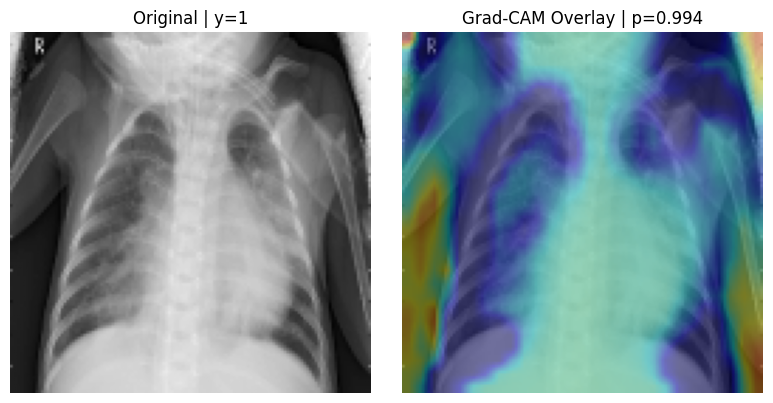

In [27]:
# ---- choose an index to inspect ----
idx = 45  # change this to try different images

# ---- grab label and run Grad-CAM ----
true_label = int(y_test.flatten()[idx])
overlay, pred_prob, img = visualize_gradcam(model, X_test_cnn, idx=idx)

# ---- side-by-side plot ----
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(np.squeeze(img), cmap="gray")
plt.title(f"Original | y={true_label}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.title(f"Grad-CAM Overlay | p={pred_prob:.3f}")
plt.axis("off")

plt.tight_layout()
plt.show()

## Discussion on results.
The figure shows the Grad-CAM overlay on a positive pnuemonia case (y=1), where the model had produced a high-confidence predicition of 0.996 (99.6%). However, the heatmap shows that the model had paid strong attention to the outside of the chest, areas that provide little clinical relevance towarads a pnuemonia diagnosis.
<br><br>
This is a clear sign of shortcut learning. The model has most likely utilised learning features that are correlated with the training data, but not related to the actual pathology (such as border lines, patient positioning and intensity gradients at the edges of the X-ray). While the model is still achieving high confidence prediction scores, the evidence from the Grad-CAM suggests that this confidence is not actually grounded to the clinically meaningful features.


# Fixing the data so that the borders are occluded and the model is retrained on that data.

After the previous results, a new approach needs to be implemented so that we can push the CNN to train on data that is relevant to the chest X-ray. An experiment to crop the peripheral's before training, which forces the model to actually focus on the fields in the lungs, reducing any chances for shortcut learning.

### First experiment 
It is important to set some basic info into a config so that way we can truely investigate if the change is effective.

In [28]:
from pathlib import Path

CONFIG = {
    "seed": 42,
    "data_root": "chest_xray",      
    "img_size": 128,                
    "batch_size": 32,
    "epochs": 50,
    "lr": 5e-4,
    "threshold": 0.5,
    "val_split_from_train": 0.2,    
    "autotune": tf.data.AUTOTUNE,
}

def set_seed_everywhere(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed_everywhere(CONFIG["seed"])

LABELS = ["NORMAL", "PNEUMONIA"]
LABEL_TO_ID = {name: i for i, name in enumerate(LABELS)}

def list_images(split_dir: str):
    """Return (paths, labels) for a directory like chest_xray/train."""
    paths, labels = [], []
    for cls in LABELS:
        cls_dir = Path(split_dir) / cls
        if not cls_dir.exists():
            continue
        for p in cls_dir.glob("*"):
            if p.suffix.lower() in [".jpeg", ".jpg", ".png"]:
                paths.append(str(p))
                labels.append(LABEL_TO_ID[cls])
    return np.array(paths), np.array(labels, dtype=np.int32)

data_root = Path(CONFIG["data_root"])
train_dir = data_root / "train"
val_dir   = data_root / "val"
test_dir  = data_root / "test"

train_paths, train_labels = list_images(str(train_dir))
test_paths,  test_labels  = list_images(str(test_dir))

if val_dir.exists():
    val_paths, val_labels = list_images(str(val_dir))
else:
    # If no official val folder, split from train in a stable, stratified way
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        train_paths,
        train_labels,
        test_size=CONFIG["val_split_from_train"],
        random_state=CONFIG["seed"],
        stratify=train_labels
    )

def describe_split(name, paths, labels):
    n = len(paths)
    pos = int(labels.sum())  # since NORMAL=0, PNEUMONIA=1
    print(f"{name}: n={n} | pneumonia={pos} ({pos/n:.1%}) | normal={n-pos} ({(n-pos)/n:.1%})")

print("=== Split summary ===")
describe_split("TRAIN", train_paths, train_labels)
describe_split("VAL",   val_paths,   val_labels)
describe_split("TEST",  test_paths,  test_labels)

IMG_SIZE = CONFIG["img_size"]

def decode_and_resize(path, label):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img_bytes, channels=1)  # grayscale
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method="bilinear")
    img = tf.cast(img, tf.float32) / 255.0            # normalize to [0,1]
    return img, tf.cast(label, tf.float32)

def make_dataset(paths, labels, training: bool):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=CONFIG["seed"], reshuffle_each_iteration=True)
    ds = ds.map(decode_and_resize, num_parallel_calls=CONFIG["autotune"])
    ds = ds.batch(CONFIG["batch_size"]).prefetch(CONFIG["autotune"])
    return ds

ds_train = make_dataset(train_paths, train_labels, training=True)
ds_val   = make_dataset(val_paths,   val_labels,   training=False)
ds_test  = make_dataset(test_paths,  test_labels,  training=False)

def build_cnn_model(input_shape=(IMG_SIZE, IMG_SIZE, 1)):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=input_shape),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    return model

model = build_cnn_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG["lr"]),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="acc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)
model.summary()

def train_model(model, ds_train, ds_val):
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=8, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=2, min_lr=1e-6),
    ]
    history = model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=CONFIG["epochs"],
        callbacks=callbacks
    )
    return history

def predict_probs(model, ds):
    probs = model.predict(ds).ravel()
    return probs

def evaluate_model(model, ds_test, y_true, threshold=0.5):
    probs = predict_probs(model, ds_test)
    preds = (probs >= threshold).astype(int)

    print("\n=== Confusion Matrix ===")
    print(confusion_matrix(y_true, preds))

    print("\n=== Classification Report ===")
    print(classification_report(y_true, preds, target_names=LABELS))

    return probs, preds

history = train_model(model, ds_train, ds_val)

test_probs, test_preds = evaluate_model(
    model=model,
    ds_test=ds_test,
    y_true=test_labels,
    threshold=CONFIG["threshold"]
)

=== Split summary ===
TRAIN: n=5216 | pneumonia=3875 (74.3%) | normal=1341 (25.7%)
VAL: n=16 | pneumonia=8 (50.0%) | normal=8 (50.0%)
TEST: n=624 | pneumonia=390 (62.5%) | normal=234 (37.5%)


/Users/eyad/Library/Python/3.11/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,313 (427.00 KB)

 Trainable params: 109,313 (427.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 20s 118ms/step - acc: 0.7412 - auc: 0.4742 - loss: 0.5882 - precision: 0.7429 - recall: 0.9964 - val_acc: 0.5000 - val_auc: 0.5625 - val_loss: 0.7690 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 19s 116ms/step - acc: 0.7906 - auc: 0.8053 - loss: 0.4547 - precision: 0.8050 - recall: 0.9479 - val_acc: 0.6250 - val_auc: 0.8438 - val_loss: 0.6834 - val_precision: 0.5714 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 19s 116ms/step - acc: 0.8531 - auc: 0.9092 - loss: 0.3305 - precision: 0.8971 - recall: 0.9063 - val_acc: 0.5625 - val_auc: 0.7969 - val_loss: 1.2625 - val_precision: 0.5333 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 19s 117ms/step - acc: 0.8748 - auc: 0.9329 - loss: 0.2828 - precision: 0.9233 - recall: 0.9068 - val_acc: 0.5625 - val_auc: 0.7969 - val_loss: 1.3461 - val_precision: 0.53

# Adaptive Foreground Detection and ROI Cropping
Purpose:
<br><br>
The following code implements an adaptive ROI extraction pipelinedesigned to seperate the thoracic area in the chest X-ray before any resizing and input into the CNN. The main goal is to reduce any bias from the background, prevent any shortcut learning and push the model to focus on anatomically important structures, allowing for improved interpretability shown using Grad-CAM. This approach, much different that fixed cropping or manual annotation, is fully automatic and will adapt to different changes in image contrast, acquisition conditions, and background appearance. 

#### Foreground-Background Separation via Edge Analysis
The function estimates which pixels are set for the background by analysing edge-connected regions, then derives a foreground mask representing the patients body.
<br><br>
Why is this medically relevant?
- Lung anatomy is central and are not connected to the borders.
- Uses edge-econnected background detection to avoid any brittle global thresholding.
- Chest X-rays backgrounds is connected to the image edges.

In [29]:
def foreground_mask_from_edge_background(image_2d, bg_percentile=10, min_bg_thr=5):
    img = image_2d.copy()
    if img.dtype != np.uint8:
        img = (img * 255).astype(np.uint8) if img.max() <= 1.0 else np.clip(img, 0, 255).astype(np.uint8)

    h, w = img.shape[:2]

    # Sample edge pixels to determine if background is dark or bright
    edge_pixels = np.concatenate([
        img[0, :], img[-1, :], img[:, 0], img[:, -1]
    ]).flatten()
    edge_mean = np.mean(edge_pixels)

    if edge_mean < 128:
        # Dark background
        thr = np.percentile(img, bg_percentile)
        thr = max(thr, min_bg_thr)
        bg_candidate = (img <= thr).astype(np.uint8)
    else:
        # Bright background
        thr = np.percentile(img, 100 - bg_percentile)
        thr = min(thr, 250)
        bg_candidate = (img >= thr).astype(np.uint8)

    ff_mask = np.zeros((h + 2, w + 2), dtype=np.uint8)
    flood_img = (1 - bg_candidate) * 255
    flood_img = flood_img.astype(np.uint8)

    seeds = [(0,0), (w-1,0), (0,h-1), (w-1,h-1),
             (w//2,0), (w//2,h-1), (0,h//2), (w-1,h//2)]
    fill_val = 128

    for sx, sy in seeds:
        if flood_img[sy, sx] == 0:
            cv.floodFill(flood_img, ff_mask, (sx, sy), fill_val)

    edge_bg = (flood_img == fill_val).astype(np.uint8)
    fg = (1 - edge_bg).astype(np.uint8)
    return fg, edge_mean  # return edge_mean instead of thr for debugging


#### Supporting Utility Functions
```apply_crop(image_2d, bbox)```
<br><br>
This applies the bounding box that was computed to the image.
<br><br>
```add_padding_to_bbox(bbox, image_shape, padding)```
<br><br>
Expands the bounding box by a fixed fraction to mitigate cutting off any important features.
<br><br>
```bbox_sanity_check(bbox, image_shape, min_area_frac)```
<br><br>
Ensures that the bounding boxes are valid and are meaningful. This protects the pipeline from pathological cases.

In [30]:

# TO apply the cropping to an image, we can use the following function:
def apply_crop(image_2d, bbox):
    if bbox is None:
        return image_2d
    x_min, y_min, x_max, y_max = bbox
    return image_2d[y_min:y_max, x_min:x_max]

def add_padding_to_bbox(bbox, image_shape, padding=0.1):
    x_min, y_min, x_max, y_max = bbox
    h, w = image_shape[:2]

    bbox_width = x_max - x_min
    bbox_height = y_max - y_min

    pad_w = int(bbox_width * padding)
    pad_h = int(bbox_height * padding)

    x_min_padded = max(0, x_min - pad_w)
    y_min_padded = max(0, y_min - pad_h)
    x_max_padded = min(w, x_max + pad_w)
    y_max_padded = min(h, y_max + pad_h)

    return (x_min_padded, y_min_padded, x_max_padded, y_max_padded)

def bbox_sanity_check(bbox, image_shape, min_area_frac=0.15):
    x_min, y_min, x_max, y_max = bbox
    h, w = image_shape[:2]

    # size check
    bbox_width = x_max - x_min
    bbox_height = y_max - y_min

    bbox_area = bbox_width * bbox_height
    image_area = w * h

    ratio = bbox_area / image_area
    if ratio < min_area_frac:
        print(f"Warning: Bounding box {bbox} is too small (area ratio {ratio:.2%} < {min_area_frac:.2%})")
        return False

    if bbox_width <= 0 or bbox_height <= 0:
        print(f"Warning: Bounding box {bbox} has zero or negative width/height")
        return False

    if x_min < 0 or y_min < 0 or x_max > w or y_max > h:
        print(f"Warning: Bounding box {bbox} is out of image bounds {image_shape}")
        return False
    if x_min >= x_max or y_min >= y_max:
        print(f"Warning: Invalid bounding box {bbox} with min >= max")
        return False
    return True


#### Morphological Refinement and Connected Component Selection
The function retains the largest contiguous foreground region, removing any noise and artifacts. We need this because:
- The thoracic region creates a single dominant structure in frontal chest X-rays.
- Small regions that are connected are not clinically relevant (labels, artfacts and noise).
- Improves robustness before bounding box extraction.
Essentially this allows the model to focus on the body rather than any artefacts in the scan.

In [31]:

def keep_largest_connected_component(mask_01: np.ndarray) -> np.ndarray:
    mask_01 = (mask_01 > 0).astype(np.uint8)

    num_labels, labels, stats, _ = cv.connectedComponentsWithStats(mask_01, connectivity=8)

    # If only background exists, return original (or all zeros)
    if num_labels <= 1:
        return np.zeros_like(mask_01, dtype=np.uint8)

    # stats[0] is background. Find largest component among 1..num_labels-1
    areas = stats[1:, cv.CC_STAT_AREA]
    largest_label = 1 + np.argmax(areas)

    clean = (labels == largest_label).astype(np.uint8)
    return clean


#### Bounding Box Extraction with Safety Constraints 
``` find_body_bbox(image)``` converts the image with a refined forehround mask into a bounding box that encloses the chest region, applies padding for anatomical safety, and includes multiple fallback mechanisms to ensure robustness. 
<br><br>
Logic of the code:
1. Foreground mask generation
- Uses edge-connected bachground detection to seperate human anatomy.
2. Morphologucal opening
- Smooths boundaries and removes thin artefacts that can interfere with the bounding box. 
3. Bounding box extraction
- The minimal bounding box is computed to enclose the foreground mask.
4. Sanity checks
- Ensures that for the bounding box:
    1. There is a non-zero area
    2. Occupies a reasonable fraction of the scan
    3. Is aligned within the valid image bounds. 
5. Padding
- Stretches the bounding box by a slight amount to mitigate truncating anatomical structures.
6. Fallback strategy
- If any of the steps fail, deploy a fixed crop.

In [32]:
def find_body_bbox(image):
    fg_mask, thr_used = foreground_mask_from_edge_background(
        image, bg_percentile=30, min_bg_thr=15
    )

    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (15, 15))
    fg_mask = cv.morphologyEx(fg_mask, cv.MORPH_OPEN, kernel)

    fg_mask = keep_largest_connected_component(fg_mask)

    coords = np.argwhere(fg_mask > 0)
    if coords.size == 0:
        h, w = image.shape[:2]
        return (int(w*0.08), int(h*0.05), int(w*0.92), int(h*0.95))

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    bbox = (x_min, y_min, x_max, y_max)

    if not bbox_sanity_check(bbox, image.shape, min_area_frac=0.08):
        h, w = image.shape[:2]
        return (int(w*0.08), int(h*0.05), int(w*0.92), int(h*0.95))

    padded_bbox = add_padding_to_bbox(bbox, image.shape, padding=0.10)

    if not bbox_sanity_check(padded_bbox, image.shape, min_area_frac=0.08):
        h, w = image.shape[:2]
        return (int(w*0.08), int(h*0.05), int(w*0.92), int(h*0.95))

    # If detected bbox covers >90% of image, use fixed crop instead
    h, w = image.shape[:2]
    x_min, y_min, x_max, y_max = padded_bbox
    if (x_max - x_min) / w > 0.90 and (y_max - y_min) / h > 0.90:
        return (int(w*0.08), int(h*0.05), int(w*0.92), int(h*0.95))

    return padded_bbox

## Resizing while preserving aspect ratio
After cropping the ROI, the input must be modified to a fixed resolution to be suitable for the CNN. Instead of explicitily changing the size of the cropped image to the desired dimensions, the project aims to preserve the original aspect ratio and apply padding when needed.
<br><br>
It is imperative to preserve the aspect ratio of the image, as any modfications to the size can distort anatomical structures. Chest X-rays with any distortions may completely change the shape or structure of the lungs and surrounding tissues can affect the machine learning and interpetabolity of the Grad-CAM visualisation. 

In [33]:
def resize_and_pad(image, target_size=(128, 128)):
    h, w = image.shape[:2]
    target_h, target_w = target_size

    # If image is emprty, return blank
    if h == 0 or w == 0:
        return np.zeros(target_size, dtype=np.float32)
    
    scale = min(target_w / w, target_h / h)
    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv.resize(image, (new_w, new_h), interpolation=cv.INTER_AREA)

    pad_w = target_w - new_w
    pad_h = target_h - new_h
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left
    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top

    padded = cv.copyMakeBorder(resized, pad_top, pad_bottom, pad_left, pad_right,
                                borderType=cv.BORDER_CONSTANT, value=0)
    return padded

### Normalise to 0-1 and add channel dimension

In [34]:
def normalise_and_expand(image):
    image = image.astype(np.float32) 
    if image.max() > 1.0:
        image = image / 255.0
    return image[..., np.newaxis]  # add channel dimension

### Baseline preproccessing
Resize then normalise

In [35]:
def preprocess_baseline(image):
    image = image.squeeze()  # (H,W,1) -> (H,W)
    image = resize_and_pad(image, target_size=(128, 128))
    return normalise_and_expand(image)

### Cropped preproccessing
Crop first, resize then normalise

In [36]:
def preprocess_cropped(image):
    image = image.squeeze()
    bbox = find_body_bbox(image)
    image_cropped = apply_crop(image, bbox)
    image_resized = resize_and_pad(image_cropped, target_size=img_size)
    image_final = normalise_and_expand(image_resized)
    return image_final

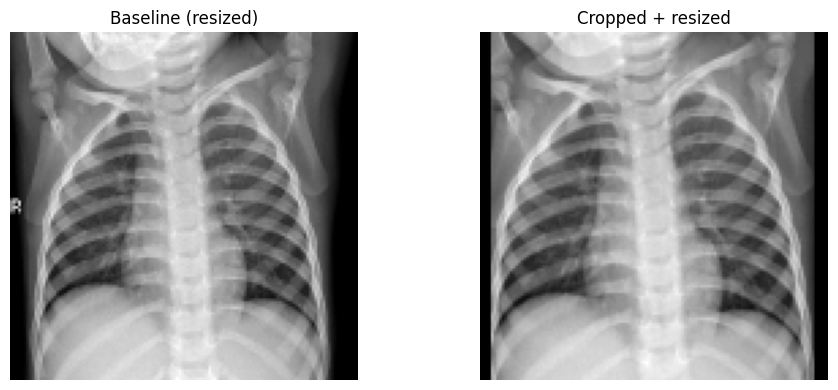

idx: 914 base shape: (128, 128) crop shape: (128, 128)


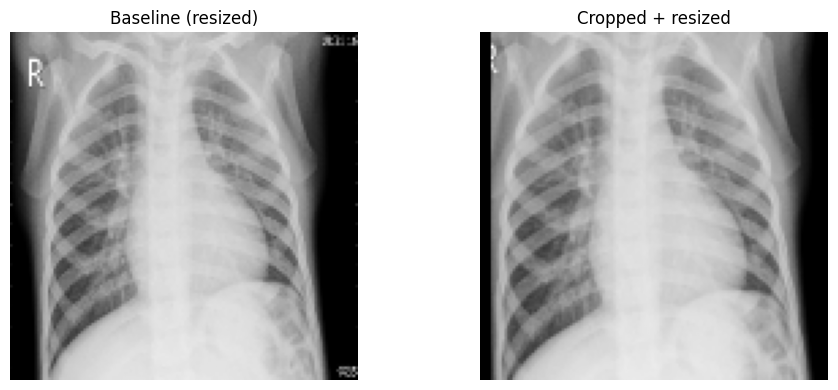

idx: 571 base shape: (128, 128) crop shape: (128, 128)


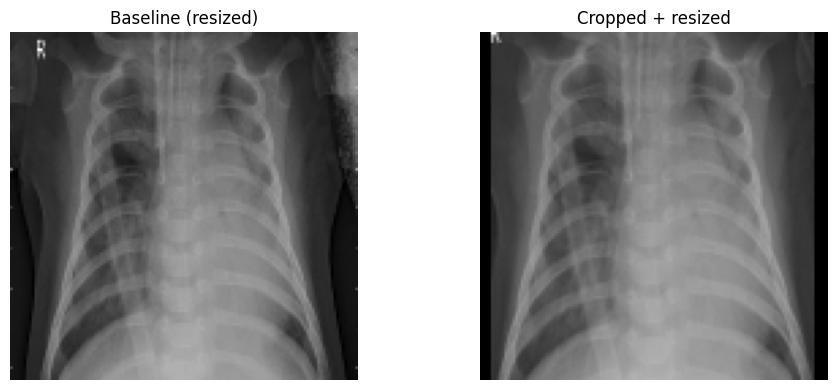

idx: 419 base shape: (128, 128) crop shape: (128, 128)


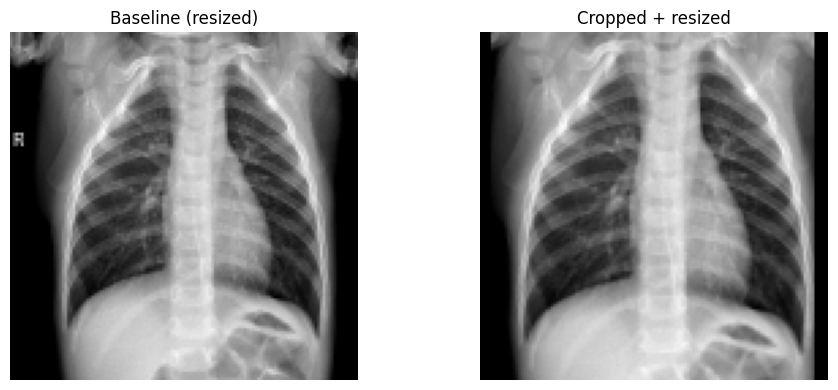

idx: 2233 base shape: (128, 128) crop shape: (128, 128)


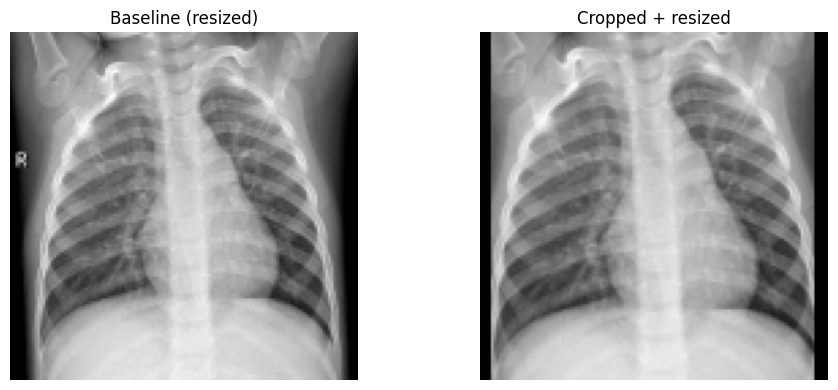

idx: 356 base shape: (128, 128) crop shape: (128, 128)


In [37]:
idx_list = random.sample(range(len(X_train_final)), 5)

for idx in idx_list:
    img = X_train_final[idx]  # (H,W,1) likely

    base = preprocess_baseline(img).squeeze()
    crop = preprocess_cropped(img).squeeze()

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(base, cmap="gray")
    plt.title("Baseline (resized)")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(crop, cmap="gray")
    plt.title("Cropped + resized")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("idx:", idx, "base shape:", base.shape, "crop shape:", crop.shape)

### Counter
In order to ensure we know what data is being cropped via the algorithm or is just cropped by force, I am going to make the code have more auditability.

In [38]:
def was_edited(bbox, image_shape, tolerance=0.05):
    if bbox is None:
        return False
    x_min, y_min, x_max, y_max = bbox
    h, w = image_shape[:2]

    return (x_min > w * tolerance)or (y_min > h * tolerance) or (x_max < w * (1 - tolerance)) or (y_max < h * (1 - tolerance))

#### Cropped Dataset Helper
```crop_split(X, y, preprocess_func, bbox_func, show_n, seed)``` creates a new dataset split, which processess each image to the cropping-based pipeline, whilst the original dataset is not modified. 
<br><br>
- X_new: the full preprocessed images
- y_new: corresponding labels 
- results: statistics describing the amount of times cropping changed the image
- example_edits: a random set of images to see how they were edited (this is more just to check to see if the function is wokring as needed)
<br><br>
This function assists the verfiication that the cropping procedure is consistantly isolating the thoracic region and doesn't act unpredictably across different cases. 


In [39]:
def crop_split(X, y, preprocess_func, bbox_func, show_n = 5, seed = 42):
    rng = np.random.default_rng(seed)

    X_new = np.zeros((len(X), 128, 128, 1), dtype=np.float32)
    y_new = np.array(y).flatten().astype(np.int32)
    edited_count = 0
    example_edits = []

    for i in range(len(X)):
        image = X[i].squeeze()

        bbox = bbox_func(image)
        if was_edited(bbox, image.shape):
            edited_count += 1

            if len(example_edits) < show_n:
                example_edits.append((i, bbox))
            else:
                if rng.random() < (show_n / edited_count):
                    j = rng.integers(0, show_n)
                    example_edits[j] = (i, bbox)
        X_new[i] = preprocess_func(X[i])

    results = {
        "Total": len(X),
        "Edited": edited_count,
        "edit rate": edited_count / len(X) if len(X) > 0 else 0,
        "Examples": example_edits
    }
    return X_new, y_new, results, example_edits

In [40]:
X_train_cropped, y_train_cropped, train_stats, train_examples = crop_split(
    X_train_final, y_train_final,
    preprocess_func=preprocess_cropped,
    bbox_func=find_body_bbox,
    show_n=5,
    seed=1
)

X_val_cropped, y_val_cropped, val_stats, val_examples = crop_split(
    X_val, y_val,
    preprocess_func=preprocess_cropped,
    bbox_func=find_body_bbox,
    show_n=5,
    seed=2
)

X_test_cropped, y_test_cropped, test_stats, test_examples = crop_split(
    X_test, y_test,
    preprocess_func=preprocess_cropped,
    bbox_func=find_body_bbox,
    show_n=5,
    seed=3
)
print("Train stats:", train_stats)
print("Val stats:", val_stats)
print("Test stats:", test_stats)

np.savez_compressed(
    "cropped_dataset.npz",
    X_train=X_train_cropped, y_train=y_train_cropped,
    X_val=X_val_cropped,     y_val=y_val_cropped,
    X_test=X_test_cropped,   y_test=y_test_cropped
)

print("Saved: cropped_dataset.npz")

Train stats: {'Total': 2502, 'Edited': 2502, 'edit rate': 1.0, 'Examples': [(173, (20, 12, 235, 243)), (1330, (20, 12, 235, 243)), (1323, (20, 12, 235, 243)), (90, (20, 12, 235, 243)), (617, (20, 12, 235, 243))]}
Val stats: {'Total': 835, 'Edited': 835, 'edit rate': 1.0, 'Examples': [(212, (20, 12, 235, 243)), (95, (20, 12, 235, 243)), (30, (20, 12, 235, 243)), (824, (20, 12, 235, 243)), (378, (20, 12, 235, 243))]}
Test stats: {'Total': 835, 'Edited': 835, 'edit rate': 1.0, 'Examples': [(831, (20, 12, 235, 243)), (762, (20, 12, 235, 243)), (467, (20, 12, 235, 243)), (728, (20, 12, 235, 243)), (316, (20, 12, 235, 243))]}
Saved: cropped_dataset.npz


In [41]:
y_train_final = y_train_final.squeeze()
y_val = y_val.squeeze()
y_test = y_test.squeeze()

In [42]:
# Baseline arrays (replace with your real variable names if needed)
print("Baseline shapes:", X_train_final.shape, y_train_final.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape)
print("Baseline label counts train:", np.bincount(y_train_final))

# Load cropped dataset from file
crop_data = np.load("cropped_dataset.npz")
X_train_crop = crop_data["X_train"]
y_train_crop = crop_data["y_train"]
X_val_crop   = crop_data["X_val"]
y_val_crop   = crop_data["y_val"]
X_test_crop  = crop_data["X_test"]
y_test_crop  = crop_data["y_test"]

print("Cropped shapes:", X_train_crop.shape, y_train_crop.shape, X_val_crop.shape, y_val_crop.shape, X_test_crop.shape, y_test_crop.shape)
print("Cropped label counts train:", np.bincount(y_train_crop))

Baseline shapes: (2502, 256, 256) (2502,) (835, 256, 256) (835,) (835, 256, 256) (835,)
Baseline label counts train: [ 643 1859]
Cropped shapes: (2502, 128, 128, 1) (2502,) (835, 128, 128, 1) (835,) (835, 128, 128, 1) (835,)
Cropped label counts train: [ 643 1859]


In [43]:
# Train model on cropped data
model_cropped = build_cnn_model(input_shape=(128, 128, 1))
model_cropped.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG["lr"]),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="acc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

ds_train_crop = tf.data.Dataset.from_tensor_slices((X_train_crop, y_train_crop)).shuffle(len(X_train_crop), seed=CONFIG["seed"]).batch(CONFIG["batch_size"]).prefetch(CONFIG["autotune"])
ds_val_crop = tf.data.Dataset.from_tensor_slices((X_val_crop, y_val_crop)).batch(CONFIG["batch_size"]).prefetch(CONFIG["autotune"])

history_cropped = train_model(model_cropped, ds_train_crop, ds_val_crop)

Epoch 1/50


/Users/eyad/Library/Python/3.11/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - acc: 0.7382 - auc: 0.4590 - loss: 0.5964 - precision: 0.7429 - recall: 0.9903 - val_acc: 0.7425 - val_auc: 0.4969 - val_loss: 0.5743 - val_precision: 0.7425 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - acc: 0.7430 - auc: 0.5354 - loss: 0.5701 - precision: 0.7430 - recall: 1.0000 - val_acc: 0.7425 - val_auc: 0.6960 - val_loss: 0.5513 - val_precision: 0.7425 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - acc: 0.7458 - auc: 0.6892 - loss: 0.5281 - precision: 0.7457 - recall: 0.9984 - val_acc: 0.7425 - val_auc: 0.8631 - val_loss: 0.4822 - val_precision: 0.7425 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - acc: 0.8050 - auc: 0.8501 - loss: 0.4276 - precision: 0.8120 - recall: 0.9597 - val_acc: 0.7545 - val_auc: 0.9306 - val_loss: 0.4510 - val_precision: 0.7515 - val_recall: 1.000

In [44]:
y_prob_crop = model_cropped.predict(X_test_crop).flatten()
y_pred_crop = (y_prob_crop >= CONFIG["threshold"]).astype(int)

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step


In [45]:
report_baseline = classification_report(y_test.flatten(), y_pred, target_names=["Normal", "Pneumonia"], labels=[0, 1])
report_cropped  = classification_report(y_test_crop.flatten(), y_pred_crop, target_names=["Normal", "Pneumonia"], labels=[0, 1])

print("=" * 45, "BASELINE MODEL", "=" * 45)
print(report_baseline)
print("=" * 45, "CROPPED MODEL", "=" * 45)
print(report_cropped)

============================================= BASELINE MODEL =============================================
              precision    recall  f1-score   support

      Normal       0.82      0.88      0.85       215
   Pneumonia       0.96      0.93      0.95       620

    accuracy                           0.92       835
   macro avg       0.89      0.91      0.90       835
weighted avg       0.92      0.92      0.92       835

============================================= CROPPED MODEL =============================================
              precision    recall  f1-score   support

      Normal       0.80      0.89      0.84       215
   Pneumonia       0.96      0.92      0.94       620

    accuracy                           0.91       835
   macro avg       0.88      0.90      0.89       835
weighted avg       0.92      0.91      0.91       835



True label: 0
Baseline prediction: 0.3053
Cropped prediction:  0.2194


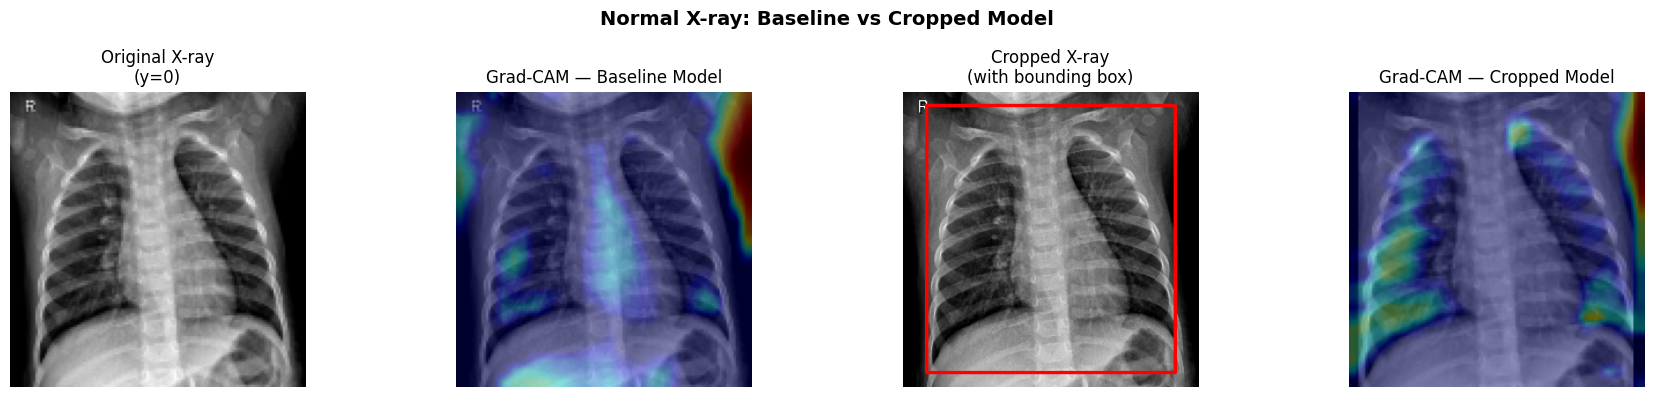

True label: 1
Baseline prediction: 0.9617
Cropped prediction:  0.9950


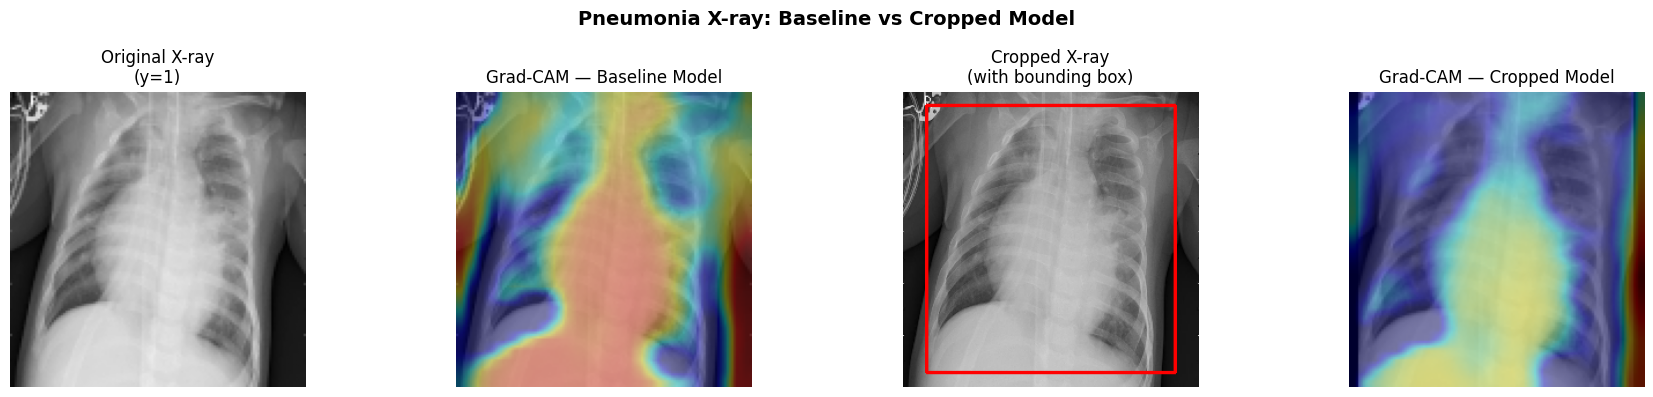

In [46]:
case_configs = [
    {"label": 0, "title": "Normal X-ray: Baseline vs Cropped Model", "idx": 5},
    {"label": 1, "title": "Pneumonia X-ray: Baseline vs Cropped Model", "idx": 4},
]

for config in case_configs:
    case_idx = config["idx"]
    true_label = int(y_test.flatten()[case_idx])

    # ---- BASELINE model ----
    overlay_base, pred_base, img_base = visualize_gradcam(model, X_test_cnn, idx=case_idx)

    # ---- CROPPED model ----
    overlay_crop, pred_crop, img_crop = visualize_gradcam(model_cropped, X_test_crop, idx=case_idx)

    # ---- Bounding box image ----
    raw_img = X_test[case_idx].squeeze()
    bbox = find_body_bbox(raw_img)
    raw_img_u8 = raw_img.astype(np.uint8) if raw_img.max() > 1 else (raw_img * 255).astype(np.uint8)
    bbox_img = cv.cvtColor(raw_img_u8, cv.COLOR_GRAY2RGB)
    if bbox is not None:
        x_min, y_min, x_max, y_max = bbox
        cv.rectangle(bbox_img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)

    print(f"True label: {true_label}")
    print(f"Baseline prediction: {pred_base:.4f}")
    print(f"Cropped prediction:  {pred_crop:.4f}")

    # ---- Plot ----
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    axes[0].imshow(np.squeeze(img_base), cmap="gray")
    axes[0].set_title(f"Original X-ray\n(y={true_label})")
    axes[0].axis("off")

    axes[1].imshow(overlay_base)
    axes[1].set_title("Grad-CAM — Baseline Model")
    axes[1].axis("off")

    axes[2].imshow(bbox_img)
    axes[2].set_title("Cropped X-ray\n(with bounding box)")
    axes[2].axis("off")

    axes[3].imshow(overlay_crop)
    axes[3].set_title("Grad-CAM — Cropped Model")
    axes[3].axis("off")

    plt.suptitle(config["title"], fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()